In this file I am going to try and create an ideal solution (perfect gaussian beam) using the methods shown here [1](https://www.flexcompute.com/tidy3d/examples/notebooks/FieldProjections/#Plot-and-compare)

In [1]:
# standard python imports
import matplotlib.pyplot as plt
import numpy as np

# tidy3d imports
import tidy3d as td
import tidy3d.web as web

In [2]:
# free space central wavelength (um)
wavelength = 0.729
# center frequency
f0 = td.C_0 / wavelength

# radial distance away from the origin at which to project fields
r_proj = 100.0
waist_radius = 2.0

In [3]:
def analytic_gaussian_beam(proj_monitor, r_proj, waist_radius):
    """
    Generates an analytical Gaussian beam pattern in a Tidy3D Far Field Data structure.
    """
    # Extract coordinates from the monitor
    x_coords = np.array(proj_monitor.x)
    y_coords = np.array(proj_monitor.y)
    z_dist = proj_monitor.proj_distance
    f0 = np.array(proj_monitor.freqs)[0]
    
    X, Y = np.meshgrid(x_coords - proj_monitor.custom_origin[0], 
                       y_coords - proj_monitor.custom_origin[1], 
                       indexing='ij')
    
    E_mag = np.exp(-(X**2 + Y**2) / (waist_radius**2))
    
    wavelength = td.C_0 / f0
    k = 2 * np.pi / wavelength
    phase = np.exp(1j * k * z_dist)

    Etheta_val = (E_mag * phase).reshape(len(x_coords), len(y_coords), 1, 1)

    # Package into Tidy3D DataArrays
    coords = dict(
        x=x_coords,
        y=y_coords,
        z=np.array([z_dist]),
        f=np.array([f0]),
    )
    
    Etheta_da = td.FieldProjectionCartesianDataArray(Etheta_val, coords=coords)
    zero_da = td.FieldProjectionCartesianDataArray(np.zeros_like(Etheta_val), coords=coords)

    return td.FieldProjectionCartesianData(
        monitor=proj_monitor,
        Er=zero_da,
        Etheta=Etheta_da,
        Ephi=zero_da,
        Hr=zero_da,
        Htheta=zero_da,
        Hphi=zero_da,
        projection_surfaces=proj_monitor.projection_surfaces,
    )


In [4]:
def make_field_plot(x, y, vals1, vals2):
    """
    Plots two field distributions side-by-side in Cartesian microns.
    Args:
        x, y: 1D arrays of spatial coordinates in microns.
        vals1, vals2: 2D arrays of field values (e.g., Ex, Ey, or Intensity).
    """
    n_plots = 2
    fig, ax = plt.subplots(1, n_plots, tight_layout=True, figsize=(10, 4.5))

    # Plotting first dataset (Analytic)
    im1 = ax[0].pcolormesh(
        x, 
        y, 
        np.real(vals1).T, # Transpose if meshgrid indexing='ij' was used
        cmap="RdBu", 
        shading="auto"
    )
    
    # Plotting second dataset (Simulation/Field Projection)
    im2 = ax[1].pcolormesh(
        x, 
        y, 
        np.real(vals2).T, 
        cmap="RdBu", 
        shading="auto"
    )
    
    # Formatting
    fig.colorbar(im1, ax=ax[0], label="Re(E)")
    fig.colorbar(im2, ax=ax[1], label="Re(E)")
    
    ax[0].set_title("Analytic Target")
    ax[1].set_title("Field Projection")
    
    for _ax in ax:
        _ax.set_xlabel(r"$x$ ($\mu$m)")
        _ax.set_ylabel(r"$y$ ($\mu$m)")
        _ax.set_aspect('equal') # Critical for seeing the true 2um circular shape
        
    plt.show()

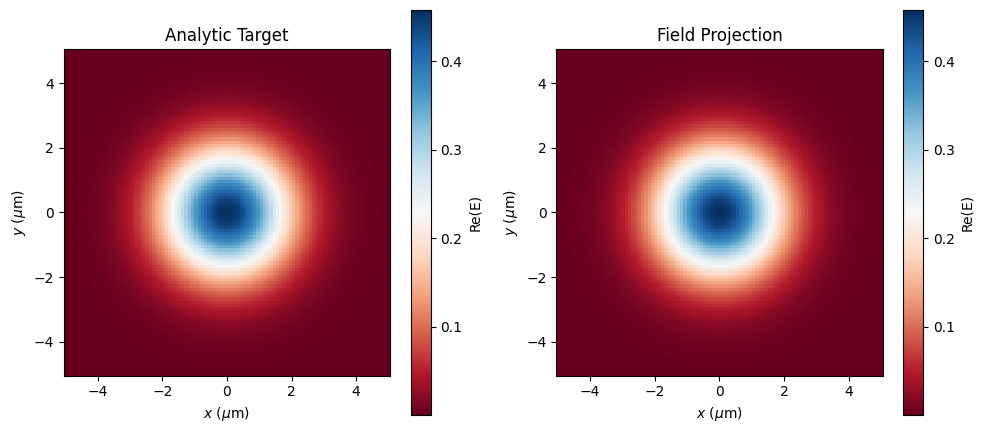

In [5]:
# theta and phi angles at which to observe fields - part of the half-space to the right
x = np.linspace(-5.0, 5.0, 100)
y = np.linspace(-5.0, 5.0, 100)

monitor_far = td.FieldProjectionCartesianMonitor(
    center=[
        0,
        0,
        0,
    ],  # the monitor's center defined the local origin - the projection distance
    # and angles will all be measured with respect to this local origin
    size=[td.inf, 0, td.inf],
    # the size and center of any far field monitor should indicate where the *near* fields are recorded
    freqs=[f0],
    name="far_field",
    x=x,
    y=y,
    custom_origin=(0,0,0),
    proj_axis=2,
    proj_distance=r_proj,
    far_field_approx=True,  # we leave this to its default value of 'True' because we are interested in fields sufficiently
    # far away that geometric far field approximations can be invoked to speed up the calculation
)

analytic_field_data = analytic_gaussian_beam(monitor_far, r_proj, waist_radius)
Etheta_analytic = analytic_field_data.Etheta.isel(f=0, z=0)
make_field_plot(x, y, Etheta_analytic, Etheta_analytic)